In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Calibration lamp data from MKS/Newport (models 6030–6033)
# Wavelengths in nm
# ============================================================

data = {
    "Kr (6031)": [
        366.53, 367.96, 377.34, 428.30, 431.96, 436.26, 437.61, 440.0,
        442.52, 445.39, 446.37, 450.24, 549.09, 550.07, 556.22, 557.03,
        558.04, 583.29, 587.09, 587.99, 599.39, 601.22, 605.61, 642.1,
        645.63, 669.92, 681.31, 690.47, 722.41, 728.98, 742.55, 748.61,
        758.74, 760.15, 768.52, 769.45, 774.68, 785.48, 791.34, 805.95,
        810.44, 811.29, 819.01, 826.32, 828.11, 829.81, 850.89, 877.67,
        892.87
    ],
    "Ne (6032)": [
        336.99, 341.79, 344.77, 345.42, 346.66, 347.26, 349.81, 350.12,
        351.52, 352.05, 359.35, 360.02, 363.37, 470.44, 492.32, 503.78,
        508.04, 511.65, 514.5, 520.39, 533.08, 534.11, 534.33, 540.06,
        564.96, 565.67, 574.83, 576.44, 580.45, 582.02, 585.25, 588.19,
        590.25, 594.48, 597.55, 598.79, 603.0, 607.43, 609.62, 612.85,
        614.31, 616.36, 618.22, 621.73, 626.65, 630.48, 631.81, 633.44,
        638.3, 640.23, 650.65, 653.29, 659.9, 665.21, 667.83, 671.7,
        692.95, 702.41, 703.24, 705.3, 705.91, 717.39, 724.52, 743.89,
        747.24, 748.89, 753.58, 754.41, 794.32, 808.25, 813.64, 830.03,
        837.76, 841.84, 849.54
    ],
    "Ar (6030)": [
        355.43, 384.9, 404.44, 415.86, 416.4, 418.19, 419.1, 419.8,
        420.07, 425.12, 425.94, 426.63, 427.22, 427.4, 430.01, 432.0,
        433.36, 434.52, 641.63, 667.73, 675.28, 687.13, 693.77, 696.54,
        703.03, 706.72, 714.7, 727.29, 737.21, 738.4, 750.39, 751.46,
        763.51, 772.38, 794.82, 800.62, 801.48, 810.37, 811.53, 826.45,
        840.82, 842.46
    ],
    "Xe (6033)": [
        450.1, 452.47, 458.28, 462.43, 467.12, 469.7, 473.42, 480.7,
        482.97, 484.33, 491.65, 502.83, 618.24, 646.97, 666.89, 672.8,
        682.73, 688.22, 711.96, 728.53, 758.47, 764.2, 823.16, 828.01,
        834.68, 840.92
    ],
}

# Create a long-format DataFrame for easier processing
rows = []
for lamp, wavelengths in data.items():
    for wl in wavelengths:
        rows.append({"Lamp": lamp, "Wavelength_nm": wl})

df_all = pd.DataFrame(rows)
print(f"Total calibration lines loaded: {len(df_all)}")
print(df_all.groupby("Lamp").count().rename(columns={"Wavelength_nm": "Total lines"}))

Total calibration lines loaded: 192
           Total lines
Lamp                  
Ar (6030)           42
Kr (6031)           49
Ne (6032)           75
Xe (6033)           26


In [3]:
def raman_shift_to_wavelength(laser_nm, raman_shift_cm):
    """
    Convert a Raman shift (cm⁻¹) to scattered wavelength (nm).
    Stokes side: positive Raman shift → longer wavelength.
    
    λ_scattered = 1e7 / (1e7/λ_laser - Δν̃)
    """
    return 1e7 / (1e7 / laser_nm - raman_shift_cm)


def wavelength_to_raman_shift(laser_nm, wavelength_nm):
    """
    Convert a scattered wavelength (nm) to Raman shift (cm⁻¹).
    """
    return 1e7 / laser_nm - 1e7 / wavelength_nm

In [4]:
def analyze_lamps(laser_nm, raman_min_cm, raman_max_cm, df=df_all, verbose=True):
    """
    For a given laser line and Raman shift range, count calibration
    lines per lamp and recommend the best one.
    
    Parameters
    ----------
    laser_nm : float
        Laser excitation wavelength in nm
    raman_min_cm : float
        Lower bound of Raman shift range in cm⁻¹
    raman_max_cm : float
        Upper bound of Raman shift range in cm⁻¹
    
    Returns
    -------
    results : DataFrame with line counts per lamp
    filtered : DataFrame with all matching lines
    """
    # Convert Raman range to wavelength window
    wl_min = raman_shift_to_wavelength(laser_nm, raman_min_cm)
    wl_max = raman_shift_to_wavelength(laser_nm, raman_max_cm)
    
    # Ensure correct ordering
    wl_min, wl_max = min(wl_min, wl_max), max(wl_min, wl_max)
    
    if verbose:
        print("=" * 65)
        print(f"  Laser wavelength    : {laser_nm:.2f} nm")
        print(f"  Raman shift range   : {raman_min_cm:.0f} – {raman_max_cm:.0f} cm⁻¹")
        print(f"  Wavelength window   : {wl_min:.2f} – {wl_max:.2f} nm")
        print("=" * 65)
    
    # Filter lines within the wavelength window
    mask = (df["Wavelength_nm"] >= wl_min) & (df["Wavelength_nm"] <= wl_max)
    filtered = df[mask].copy()
    filtered["Raman_shift_cm"] = wavelength_to_raman_shift(laser_nm, filtered["Wavelength_nm"])
    filtered = filtered.sort_values("Wavelength_nm").reset_index(drop=True)
    
    # Count per lamp
    counts = filtered.groupby("Lamp").size().reset_index(name="Lines_in_range")
    
    # Add lamps with 0 lines
    all_lamps = df["Lamp"].unique()
    for lamp in all_lamps:
        if lamp not in counts["Lamp"].values:
            counts = pd.concat([counts, pd.DataFrame({"Lamp": [lamp], "Lines_in_range": [0]})],
                               ignore_index=True)
    
    # Calculate average spacing (nm) between consecutive lines
    avg_spacing = []
    for lamp in counts["Lamp"]:
        lamp_lines = filtered[filtered["Lamp"] == lamp]["Wavelength_nm"].sort_values().values
        if len(lamp_lines) > 1:
            spacings = np.diff(lamp_lines)
            avg_spacing.append(f"{np.mean(spacings):.2f}")
        else:
            avg_spacing.append("N/A")
    counts["Avg_spacing_nm"] = avg_spacing
    
    # Sort by number of lines descending
    counts = counts.sort_values("Lines_in_range", ascending=False).reset_index(drop=True)
    
    # Determine the best lamp
    best_lamp = counts.iloc[0]["Lamp"]
    best_count = counts.iloc[0]["Lines_in_range"]
    
    if verbose:
        print("\n📊 Calibration lines per lamp in the spectral window:\n")
        print(counts.to_string(index=False))
        print(f"\n✅ RECOMMENDED LAMP: **{best_lamp}** with {best_count} lines in range\n")
        
        # Show the actual lines for the best lamp
        best_lines = filtered[filtered["Lamp"] == best_lamp].copy()
        if len(best_lines) > 0:
            print(f"📋 Lines for {best_lamp} in range:")
            print(best_lines[["Wavelength_nm", "Raman_shift_cm"]].to_string(index=False))
    
    return counts, filtered

In [5]:
def plot_lamps_in_range(laser_nm, raman_min_cm, raman_max_cm, filtered, counts):
    """
    Visual overview of calibration lines in the Raman window.
    """
    wl_min = raman_shift_to_wavelength(laser_nm, raman_min_cm)
    wl_max = raman_shift_to_wavelength(laser_nm, raman_max_cm)
    wl_min, wl_max = min(wl_min, wl_max), max(wl_min, wl_max)
    
    colors = {
        "Kr (6031)": "#e63946",
        "Ne (6032)": "#f4a261",
        "Ar (6030)": "#2a9d8f",
        "Xe (6033)": "#457b9d",
    }
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), 
                                     gridspec_kw={"height_ratios": [3, 1]})
    
    # --- Top panel: lines on wavelength axis ---
    for i, lamp in enumerate(colors.keys()):
        lamp_lines = filtered[filtered["Lamp"] == lamp]["Wavelength_nm"].values
        if len(lamp_lines) > 0:
            ax1.vlines(lamp_lines, i - 0.35, i + 0.35, colors=colors[lamp], 
                       linewidth=1.5, label=lamp)
            ax1.scatter(lamp_lines, [i] * len(lamp_lines), color=colors[lamp], 
                       s=20, zorder=5)
    
    ax1.set_yticks(range(len(colors)))
    ax1.set_yticklabels(list(colors.keys()), fontsize=12)
    ax1.set_xlabel("Wavelength (nm)", fontsize=12)
    ax1.set_title(
        f"Calibration Lines in Raman Window\n"
        f"Laser: {laser_nm} nm | Range: {raman_min_cm}–{raman_max_cm} cm⁻¹ "
        f"({wl_min:.1f}–{wl_max:.1f} nm)",
        fontsize=13, fontweight="bold"
    )
    ax1.axvline(laser_nm, color="red", linestyle="--", alpha=0.5, label="Laser line")
    ax1.set_xlim(wl_min - 10, wl_max + 10)
    ax1.grid(axis="x", alpha=0.3)
    ax1.legend(loc="upper right", fontsize=9)
    
    # --- Bottom panel: bar chart of line counts ---
    lamps_sorted = counts.sort_values("Lines_in_range", ascending=True)
    bar_colors = [colors.get(l, "gray") for l in lamps_sorted["Lamp"]]
    bars = ax2.barh(lamps_sorted["Lamp"], lamps_sorted["Lines_in_range"], 
                    color=bar_colors, edgecolor="white", height=0.6)
    
    for bar, val in zip(bars, lamps_sorted["Lines_in_range"]):
        ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{val}", va="center", fontsize=11, fontweight="bold")
    
    ax2.set_xlabel("Number of calibration lines in range", fontsize=12)
    ax2.set_title("Line Count Comparison", fontsize=12)
    ax2.grid(axis="x", alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig("calibration_lamp_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print("💾 Figure saved as 'calibration_lamp_analysis.png'")

  Laser wavelength    : 633.00 nm
  Raman shift range   : 2500 – 4000 cm⁻¹
  Wavelength window   : 752.00 – 847.62 nm

📊 Calibration lines per lamp in the spectral window:

     Lamp  Lines_in_range Avg_spacing_nm
Kr (6031)              14           5.47
Ar (6030)              10           8.77
Ne (6032)               8          12.61
Xe (6033)               6          16.49

✅ RECOMMENDED LAMP: **Kr (6031)** with 14 lines in range

📋 Lines for Kr (6031) in range:
 Wavelength_nm  Raman_shift_cm
        758.74     2618.042942
        760.15     2642.490013
        768.52     2785.765200
        769.45     2801.492254
        774.68     2889.232519
        785.48     3066.719409
        791.34     3160.995022
        805.95     3390.070709
        810.44     3458.811951
        811.29     3471.739671
        819.01     3587.925182
        826.32     3695.939147
        828.11     3722.097882
        829.81     3746.836887


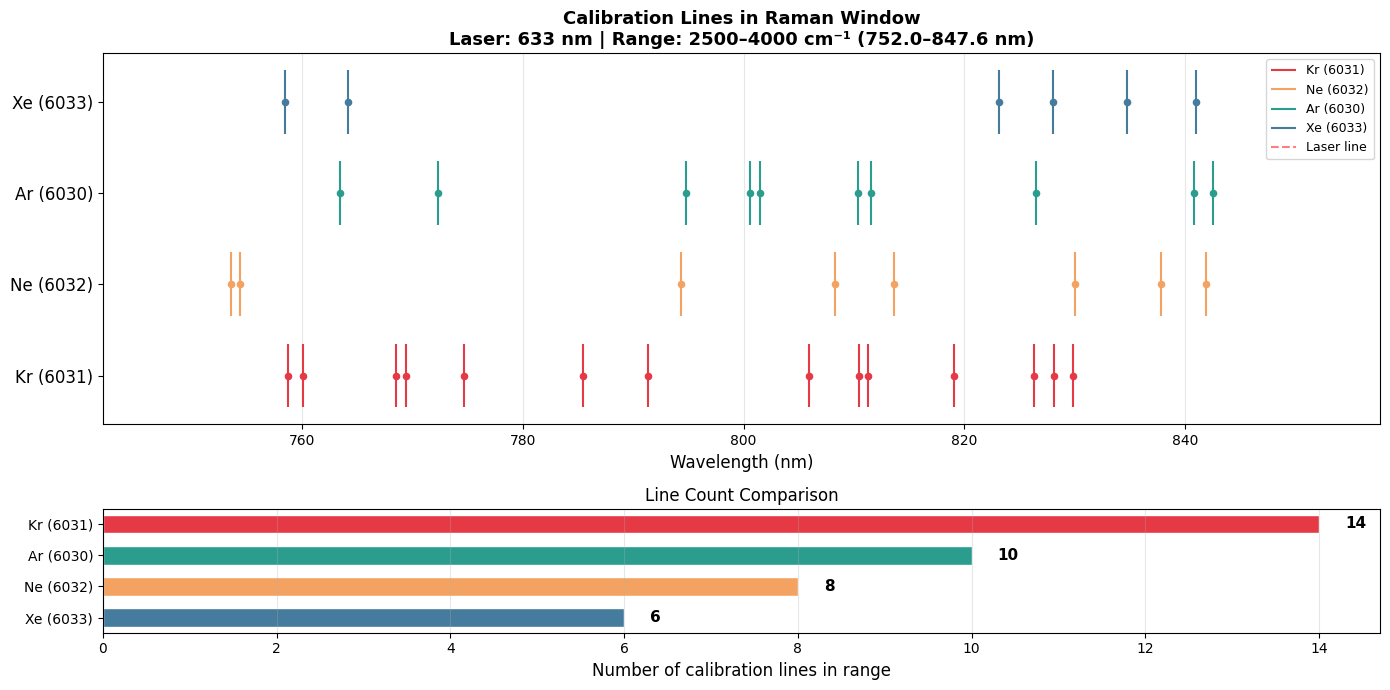

💾 Figure saved as 'calibration_lamp_analysis.png'


In [41]:
# ╔══════════════════════════════════════════════════════════╗
# ║         ✏️  SET YOUR PARAMETERS HERE                    ║
# ╚══════════════════════════════════════════════════════════╝

LASER_WAVELENGTH_NM = 633      # e.g., 532, 633, 785, 1064 ...
RAMAN_SHIFT_MIN_CM  = 2500         # lower bound in cm⁻¹
RAMAN_SHIFT_MAX_CM  = 4000    # upper bound in cm⁻¹

# Run analysis
counts, filtered = analyze_lamps(
    laser_nm      = LASER_WAVELENGTH_NM,
    raman_min_cm  = RAMAN_SHIFT_MIN_CM,
    raman_max_cm  = RAMAN_SHIFT_MAX_CM,
)

# Plot
plot_lamps_in_range(
    laser_nm      = LASER_WAVELENGTH_NM,
    raman_min_cm  = RAMAN_SHIFT_MIN_CM,
    raman_max_cm  = RAMAN_SHIFT_MAX_CM,
    filtered      = filtered,
    counts        = counts,
)